# Laptop Brand Preferences: Business vs Engineering Students at Concordia

**ENGR 371**

**Date:** November 2025


## 1. Setup and Import Libraries

We'll use standard Python libraries for data analysis and visualization.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
# warnings.filterwarnings('ignore')

# Set matplotlib to display inline
%matplotlib inline

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully")
print(f"Analysis date: {pd.Timestamp.now().strftime('%B %d, %Y')}")


✓ Libraries imported successfully
Analysis date: May 14, 2026


## 2. Load and Inspect Data

Data was collected through direct observation in JMSB and Hall Building study areas over 5 days (October 20-24, 2025).



In [2]:
# Loading the data
df = pd.read_csv('laptop_study_data1.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 observations:")
display(df.head())

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (12, 6)

First 5 observations:


,Building,Date,Time,Specific Location,Number of Macs,Number of Windows
0,JMSB,2025-10-20,09:30,JMSB Open Study Area,4,2
1,JMSB,2025-10-20,14:15,JMSB 2nd Floor,3,4
2,JMSB,2025-10-22,09:15,JMSB Open Study Area,6,2
3,JMSB,2025-10-22,11:50,JMSB 2nd Floor,3,5
4,JMSB,2025-10-23,14:00,JMSB Open Study Area,7,3



Column data types:
Building               str
Date                   str
Time                   str
Specific Location      str
Number of Macs       int64
Number of Windows    int64
dtype: object

Missing values:
Building             0
Date                 0
Time                 0
Specific Location    0
Number of Macs       0
Number of Windows    0
dtype: int64


## 3. Data Collection Summary

Let's examine the scope and distribution of our data collection effort.

In [3]:
# Calculate summary statistics
total_sessions = len(df)
jmsb_sessions = len(df[df['Building'] == 'JMSB'])
hall_sessions = len(df[df['Building'] == 'Hall Building'])

unique_dates = df['Date'].nunique()
date_range = f"{df['Date'].min()} to {df['Date'].max()}"

print("DATA COLLECTION SUMMARY:")

print(f"\nTotal observation sessions: {total_sessions}")
print(f"  • JMSB (Business): {jmsb_sessions} sessions")
print(f"  • Hall Building (Engineering): {hall_sessions} sessions")
print(f"\nData collection period: {unique_dates} days ({date_range})")

print("\nObservation locations:")
location_counts = df.groupby(['Building', 'Specific Location']).size()
print(location_counts.to_string())

DATA COLLECTION SUMMARY:

Total observation sessions: 12
  • JMSB (Business): 6 sessions
  • Hall Building (Engineering): 6 sessions

Data collection period: 4 days (2025-10-20 to 2025-10-24)

Observation locations:
Building       Specific Location   
Hall Building  Hall 8th Floor          3
               Hall Ground Floor       3
JMSB           JMSB 2nd Floor          3
               JMSB Open Study Area    3



**Project Requirement:** Calculate mean, median, variance, and standard deviation.

Our **sample** consists of Mac usage percentages from each observation session (n=12).

In [4]:
# Calculate Mac percentage for each session
df['Total_Laptops'] = df['Number of Macs'] + df['Number of Windows']
df['Mac_Percentage'] = (df['Number of Macs'] / df['Total_Laptops'] * 100)

print("ALL SAMPLE VALUES (Mac Percentage Per Session)")

print("\nOur sample consists of 12 observation sessions:")
print()
for idx, row in df.iterrows():
    print(f"Session {idx+1:2d}: {row['Building']:<20} {row['Date']:<12} "
          f"{row['Specific Location']:<30} Mac: {row['Mac_Percentage']:>6.2f}%")

# Separate by building for analysis
jmsb_percentages = df[df['Building'] == 'JMSB']['Mac_Percentage'].values
hall_percentages = df[df['Building'] == 'Hall Building']['Mac_Percentage'].values

print("SAMPLE VALUES BY BUILDING")

print(f"\nJMSB (Business): Mac % for each session (n={len(jmsb_percentages)}):")
for i, val in enumerate(jmsb_percentages, 1):
    print(f"  Session {i}: {val:.2f}%")

print(f"\nHall Building (Engineering): Mac % for each session (n={len(hall_percentages)}):")
for i, val in enumerate(hall_percentages, 1):
    print(f"  Session {i}: {val:.2f}%")

ALL SAMPLE VALUES (Mac Percentage Per Session)

Our sample consists of 12 observation sessions:

Session  1: JMSB                 2025-10-20   JMSB Open Study Area           Mac:  66.67%
Session  2: JMSB                 2025-10-20   JMSB 2nd Floor                 Mac:  42.86%
Session  3: JMSB                 2025-10-22   JMSB Open Study Area           Mac:  75.00%
Session  4: JMSB                 2025-10-22   JMSB 2nd Floor                 Mac:  37.50%
Session  5: JMSB                 2025-10-23   JMSB Open Study Area           Mac:  70.00%
Session  6: JMSB                 2025-10-24   JMSB 2nd Floor                 Mac:  66.67%
Session  7: Hall Building        2025-10-20   Hall Ground Floor              Mac:  28.57%
Session  8: Hall Building        2025-10-20   Hall 8th Floor                 Mac:  20.00%
Session  9: Hall Building        2025-10-22   Hall Ground Floor              Mac:  37.50%
Session 10: Hall Building        2025-10-23   Hall 8th Floor                 Mac:  28.57%
Ses

In [5]:
import numpy as np

# Calculate REQUIRED statistics for JMSB
jmsb_mean = np.mean(jmsb_percentages)
jmsb_median = np.median(jmsb_percentages)
jmsb_variance = np.var(jmsb_percentages, ddof=1)  # Sample variance (n-1)
jmsb_std = np.std(jmsb_percentages, ddof=1)       # Sample std dev (n-1)

# Calculate REQUIRED statistics for Hall Building
hall_mean = np.mean(hall_percentages)
hall_median = np.median(hall_percentages)
hall_variance = np.var(hall_percentages, ddof=1)
hall_std = np.std(hall_percentages, ddof=1)

# Calculate for overall sample (all 12 sessions combined)
all_percentages = np.concatenate([jmsb_percentages, hall_percentages])
overall_mean = np.mean(all_percentages)
overall_median = np.median(all_percentages)
overall_variance = np.var(all_percentages, ddof=1)
overall_std = np.std(all_percentages, ddof=1)

print("STATISTICS: DESCRIPTIVE MEASURES")


print("JMSB (Business): Mac Usage Percentage")

print(f"Sample size (n):          {len(jmsb_percentages)}")
print(f"Sample mean (x̄):          {jmsb_mean:.4f}%")
print(f"Sample median:            {jmsb_median:.4f}%")
print(f"Sample variance (s²):     {jmsb_variance:.4f}")
print(f"Sample std deviation (s): {jmsb_std:.4f}")


print("Hall Building (Engineering): Mac Usage Percentage")

print(f"Sample size (n):          {len(hall_percentages)}")
print(f"Sample mean (x̄):          {hall_mean:.4f}%")
print(f"Sample median:            {hall_median:.4f}%")
print(f"Sample variance (s²):     {hall_variance:.4f}")
print(f"Sample std deviation (s): {hall_std:.4f}")


print("Overall Sample (All 12 Sessions Combined)")

print(f"Sample size (n):          {len(all_percentages)}")
print(f"Sample mean (x̄):          {overall_mean:.4f}%")
print(f"Sample median:            {overall_median:.4f}%")
print(f"Sample variance (s²):     {overall_variance:.4f}")
print(f"Sample std deviation (s): {overall_std:.4f}")


print("INTERPRETATION")

print(f"\nThe mean Mac usage in JMSB ({jmsb_mean:.2f}%) is {jmsb_mean - hall_mean:.2f}")
print(f"percentage points higher than in Hall Building ({hall_mean:.2f}%).")
print(f"\nVariability: JMSB has standard deviation of {jmsb_std:.2f}% while")
print(f"Hall Building has {hall_std:.2f}%, indicating JMSB shows")
print(f"{'more' if jmsb_std > hall_std else 'less'} variability in laptop preferences.")




STATISTICS: DESCRIPTIVE MEASURES
JMSB (Business): Mac Usage Percentage
Sample size (n):          6
Sample mean (x̄):          59.7817%
Sample median:            66.6667%
Sample variance (s²):     242.7461
Sample std deviation (s): 15.5803
Hall Building (Engineering): Mac Usage Percentage
Sample size (n):          6
Sample mean (x̄):          32.0701%
Sample median:            30.9524%
Sample variance (s²):     70.8745
Sample std deviation (s): 8.4187
Overall Sample (All 12 Sessions Combined)
Sample size (n):          12
Sample mean (x̄):          45.9259%
Sample median:            40.1786%
Sample variance (s²):     351.9917
Sample std deviation (s): 18.7614
INTERPRETATION

The mean Mac usage in JMSB (59.78%) is 27.71
percentage points higher than in Hall Building (32.07%).

Variability: JMSB has standard deviation of 15.58% while
Hall Building has 8.42%, indicating JMSB shows
more variability in laptop preferences.


/var/folders/38/lzsfz06d1vvddkw8sk_1v4qr0000gn/T/ipykernel_65108/65835345.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=['JMSB\n(Business)', 'Hall Building\n(Engineering)'],


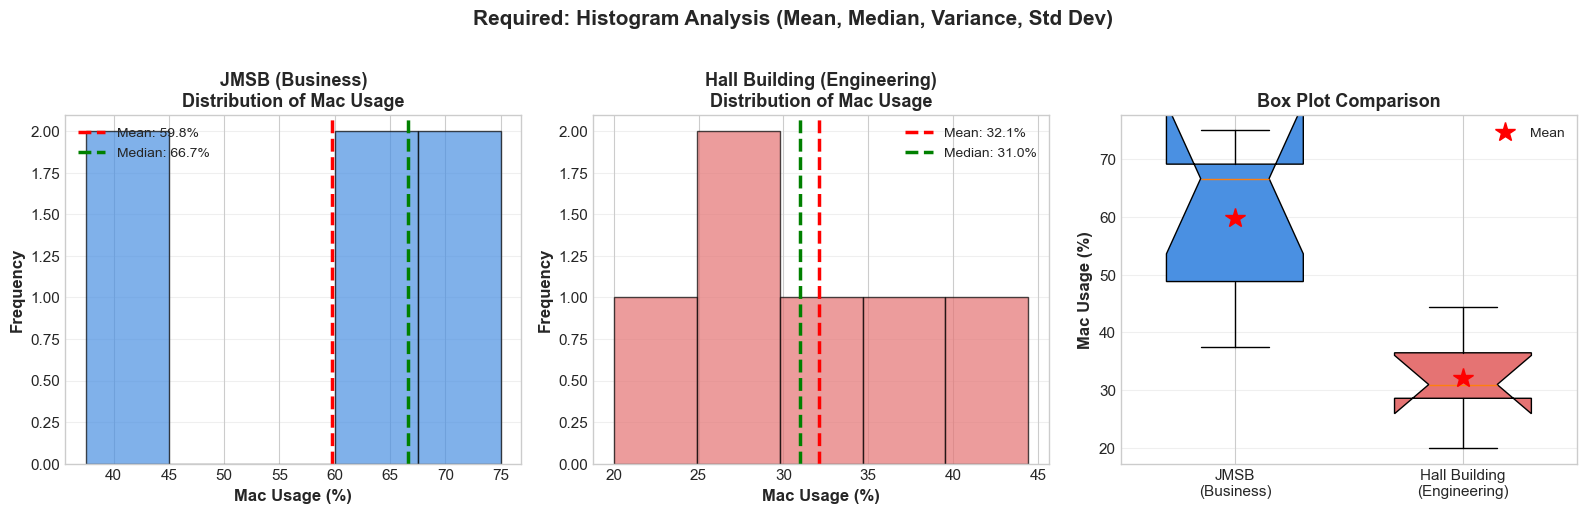

Histograms show the distribution of Mac usage percentages across
observation sessions, with mean and median values marked.


In [6]:
# Create histograms with mean and median lines
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# JMSB Histogram
ax1 = axes[0]
ax1.hist(jmsb_percentages, bins=5, color='#4A90E2', edgecolor='black', alpha=0.7)
ax1.axvline(jmsb_mean, color='red', linestyle='--', linewidth=2.5,
            label=f'Mean: {jmsb_mean:.1f}%')
ax1.axvline(jmsb_median, color='green', linestyle='--', linewidth=2.5,
            label=f'Median: {jmsb_median:.1f}%')
ax1.set_xlabel('Mac Usage (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('JMSB (Business)\nDistribution of Mac Usage', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Hall Building Histogram
ax2 = axes[1]
ax2.hist(hall_percentages, bins=5, color='#E57373', edgecolor='black', alpha=0.7)
ax2.axvline(hall_mean, color='red', linestyle='--', linewidth=2.5,
            label=f'Mean: {hall_mean:.1f}%')
ax2.axvline(hall_median, color='green', linestyle='--', linewidth=2.5,
            label=f'Median: {hall_median:.1f}%')
ax2.set_xlabel('Mac Usage (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Hall Building (Engineering)\nDistribution of Mac Usage',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Box plot comparison
ax3 = axes[2]
box_data = [jmsb_percentages, hall_percentages]
bp = ax3.boxplot(box_data, labels=['JMSB\n(Business)', 'Hall Building\n(Engineering)'],
                  patch_artist=True, notch=True, widths=0.6)
bp['boxes'][0].set_facecolor('#4A90E2')
bp['boxes'][1].set_facecolor('#E57373')
ax3.plot([1], [jmsb_mean], 'r*', markersize=15, label='Mean', zorder=3)
ax3.plot([2], [hall_mean], 'r*', markersize=15, zorder=3)
ax3.set_ylabel('Mac Usage (%)', fontsize=12, fontweight='bold')
ax3.set_title('Box Plot Comparison', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Required: Histogram Analysis (Mean, Median, Variance, Std Dev)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Histograms show the distribution of Mac usage percentages across")
print("observation sessions, with mean and median values marked.")


## 3D. Two-Sample T-Test (Comparing Means)

Testing whether the mean Mac usage differs significantly between the two buildings.

In [7]:
from scipy.stats import ttest_ind

# Perform two-sample t-test
t_stat, t_pvalue = ttest_ind(jmsb_percentages, hall_percentages)

print("TWO-SAMPLE T-TEST")

print(f"\nNull Hypothesis (H₀):        μ_JMSB = μ_Hall")
print(f"Alternative Hypothesis (H₁):  μ_JMSB ≠ μ_Hall")
print(f"Significance level:           α = 0.05")

print(f"\nTest Results:")
print(f"  t-statistic:     {t_stat:.4f}")
print(f"  p-value:         {t_pvalue:.6f}")
print(f"  df:              {len(jmsb_percentages) + len(hall_percentages) - 2}")

print(f"\nDecision:")
if t_pvalue < 0.05:
    print(f"  ✓ REJECT H₀ (p = {t_pvalue:.4f} < 0.05)")
    print(f"  Conclusion: The mean Mac usage IS significantly different")
    print(f"              between JMSB and Hall Building.")
else:
    print(f"  ✗ FAIL TO REJECT H₀ (p = {t_pvalue:.4f} ≥ 0.05)")
    print(f"  Conclusion: No significant difference in means detected.")

# Calculate effect size (Cohen's d)
pooled_std = np.sqrt(((len(jmsb_percentages)-1)*jmsb_variance +
                      (len(hall_percentages)-1)*hall_variance) /
                     (len(jmsb_percentages) + len(hall_percentages) - 2))
cohens_d = (jmsb_mean - hall_mean) / pooled_std

print(f"\nEffect Size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"Interpretation: {effect_interpretation.upper()} effect")
print(f"\n(Cohen's guidelines: small ≈ 0.2, medium ≈ 0.5, large ≈ 0.8)")

TWO-SAMPLE T-TEST

Null Hypothesis (H₀):        μ_JMSB = μ_Hall
Alternative Hypothesis (H₁):  μ_JMSB ≠ μ_Hall
Significance level:           α = 0.05

Test Results:
  t-statistic:     3.8330
  p-value:         0.003303
  df:              10

Decision:
  ✓ REJECT H₀ (p = 0.0033 < 0.05)
  Conclusion: The mean Mac usage IS significantly different
              between JMSB and Hall Building.

Effect Size (Cohen's d): 2.2130
Interpretation: LARGE effect

(Cohen's guidelines: small ≈ 0.2, medium ≈ 0.5, large ≈ 0.8)


## 4. Calculate Total Laptops Observed

Aggregate laptop counts by building to prepare for statistical analysis.

In [8]:
# Add total column
df['Total'] = df['Number of Macs'] + df['Number of Windows']

# Aggregate by building
summary = df.groupby('Building').agg({
    'Number of Macs': 'sum',
    'Number of Windows': 'sum',
    'Total': 'sum'
}).reset_index()

summary['Mac %'] = (summary['Number of Macs'] / summary['Total'] * 100).round(1)
summary['Windows %'] = (summary['Number of Windows'] / summary['Total'] * 100).round(1)


print("AGGREGATE LAPTOP COUNTS BY BUILDING:")

display(summary)

# Store values for later use
jmsb_macs = summary[summary['Building'] == 'JMSB']['Number of Macs'].values[0]
jmsb_windows = summary[summary['Building'] == 'JMSB']['Number of Windows'].values[0]
jmsb_total = summary[summary['Building'] == 'JMSB']['Total'].values[0]

hall_macs = summary[summary['Building'] == 'Hall Building']['Number of Macs'].values[0]
hall_windows = summary[summary['Building'] == 'Hall Building']['Number of Windows'].values[0]
hall_total = summary[summary['Building'] == 'Hall Building']['Total'].values[0]

total_laptops = jmsb_total + hall_total

print(f"\nTotal laptops observed: {total_laptops}")
print(f"Target sample size: 100")
print(f"Achievement: {(total_laptops/100*100):.0f}% of target ✓")


AGGREGATE LAPTOP COUNTS BY BUILDING:


,Building,Number of Macs,Number of Windows,Total,Mac %,Windows %
0,Hall Building,14,28,42,33.3,66.7
1,JMSB,27,18,45,60.0,40.0



Total laptops observed: 87
Target sample size: 100
Achievement: 87% of target ✓


## 5. Descriptive Statistics

Calculate proportions and 95% confidence intervals for each group.

In [9]:
# Calculate proportions
prop_jmsb_mac = jmsb_macs / jmsb_total
prop_hall_mac = hall_macs / hall_total

# Calculate 95% confidence intervals
ci_jmsb = 1.96 * np.sqrt(prop_jmsb_mac * (1 - prop_jmsb_mac) / jmsb_total)
ci_hall = 1.96 * np.sqrt(prop_hall_mac * (1 - prop_hall_mac) / hall_total)

print("DESCRIPTIVE STATISTICS")

print(f"\nJMSB (Business) - n = {jmsb_total}")
print(f"  Mac users: {jmsb_macs} ({prop_jmsb_mac*100:.1f}%)")
print(f"  95% CI: [{(prop_jmsb_mac - ci_jmsb)*100:.1f}%, {(prop_jmsb_mac + ci_jmsb)*100:.1f}%]")

print(f"\nHall Building (Engineering) - n = {hall_total}")
print(f"  Mac users: {hall_macs} ({prop_hall_mac*100:.1f}%)")
print(f"  95% CI: [{(prop_hall_mac - ci_hall)*100:.1f}%, {(prop_hall_mac + ci_hall)*100:.1f}%]")

diff = (prop_jmsb_mac - prop_hall_mac) * 100
print(f"\nDifference in proportions: {diff:.1f} percentage points")
print(f"(JMSB has {diff:.1f}pp higher Mac usage)")

DESCRIPTIVE STATISTICS

JMSB (Business) - n = 45
  Mac users: 27 (60.0%)
  95% CI: [45.7%, 74.3%]

Hall Building (Engineering) - n = 42
  Mac users: 14 (33.3%)
  95% CI: [19.1%, 47.6%]

Difference in proportions: 26.7 percentage points
(JMSB has 26.7pp higher Mac usage)


## 6. Visualization: Proportions with Confidence Intervals

Let's visualize the key finding - the difference in Mac usage between the two programs.

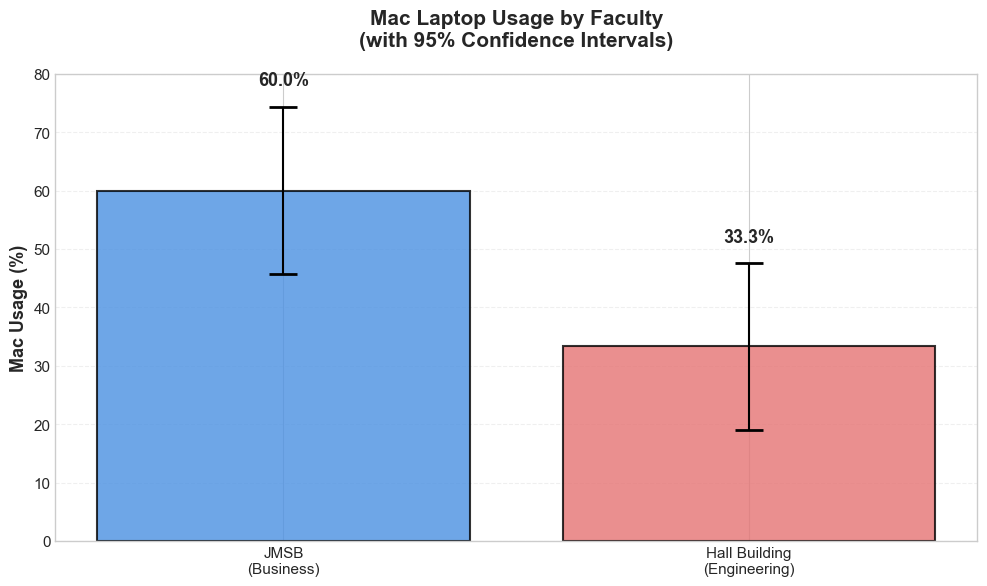

Key observation: JMSB shows substantially higher Mac usage with non-overlapping confidence intervals.


In [10]:
# Create bar chart with error bars
fig, ax = plt.subplots(figsize=(10, 6))

buildings = ['JMSB\n(Business)', 'Hall Building\n(Engineering)']
mac_percentages = [prop_jmsb_mac * 100, prop_hall_mac * 100]
errors = [ci_jmsb * 100, ci_hall * 100]

colors = ['#4A90E2', '#E57373']
bars = ax.bar(buildings, mac_percentages, color=colors, alpha=0.8,
              edgecolor='black', linewidth=1.5)

# Add error bars
ax.errorbar(buildings, mac_percentages, yerr=errors, fmt='none',
            ecolor='black', capsize=10, capthick=2)

# Customize plot
ax.set_ylabel('Mac Usage (%)', fontsize=13, fontweight='bold')
ax.set_title('Mac Laptop Usage by Faculty\n(with 95% Confidence Intervals)',
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylim(0, 80)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage labels
for i, (bar, pct) in enumerate(zip(bars, mac_percentages)):
    ax.text(bar.get_x() + bar.get_width()/2, pct + errors[i] + 3,
            f'{pct:.1f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("Key observation: JMSB shows substantially higher Mac usage with non-overlapping confidence intervals.")

## 7. Contingency Table

Construct the 2×2 contingency table for chi-square analysis.

In [11]:
# Create contingency table
contingency_table = np.array([
    [jmsb_macs, jmsb_windows],
    [hall_macs, hall_windows]
])

print("CONTINGENCY TABLE")

# Create formatted DataFrame
cont_df = pd.DataFrame(
    contingency_table,
    index=['JMSB (Business)', 'Hall (Engineering)'],
    columns=['Mac', 'Windows']
)
cont_df['Total'] = cont_df.sum(axis=1)
cont_df.loc['Total'] = cont_df.sum()

display(cont_df)

CONTINGENCY TABLE


,Mac,Windows,Total
JMSB (Business),27,18,45
Hall (Engineering),14,28,42
Total,41,46,87


## 8. Chi-Square Test of Independence

Primary statistical test to determine if there's an association between program and laptop brand.

In [12]:
# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nCHI-SQUARE TEST OF INDEPENDENCE:\n")

print(f"\nTest Statistic: χ² = {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.6f}")
print(f"Critical Value (α=0.05): 3.841")

print("\nExpected Frequencies under H₀:")
expected_df = pd.DataFrame(
    expected,
    index=['JMSB (Business)', 'Hall (Engineering)'],
    columns=['Mac', 'Windows']
)
display(expected_df.round(2))

# Check assumptions
min_expected = expected.min()
print(f"\nAssumption Check:")
print(f"  Minimum expected frequency: {min_expected:.2f}")
if min_expected >= 5:
    print(f"  ✓ All expected frequencies ≥ 5 (assumption met)")
else:
    print(f"  ✗ Some expected frequencies < 5 (consider Fisher's exact test)")

# Decision
print("\nDECISION:")

if p_value < 0.05:
    print(f"✓ REJECT H₀ (p = {p_value:.4f} < 0.05)")
    print(f"\nThere IS a statistically significant association between")
    print(f"academic program and laptop brand preference.")
else:
    print(f"✗ FAIL TO REJECT H₀ (p = {p_value:.4f} ≥ 0.05)")
    print(f"\nNo statistically significant association detected.")



CHI-SQUARE TEST OF INDEPENDENCE:


Test Statistic: χ² = 5.1758
Degrees of Freedom: 1
P-value: 0.022904
Critical Value (α=0.05): 3.841

Expected Frequencies under H₀:


,Mac,Windows
JMSB (Business),21.21,23.79
Hall (Engineering),19.79,22.21



Assumption Check:
  Minimum expected frequency: 19.79
  ✓ All expected frequencies ≥ 5 (assumption met)

DECISION:
✓ REJECT H₀ (p = 0.0229 < 0.05)

There IS a statistically significant association between
academic program and laptop brand preference.


## 9. Visualization: Chi-Square Test Result

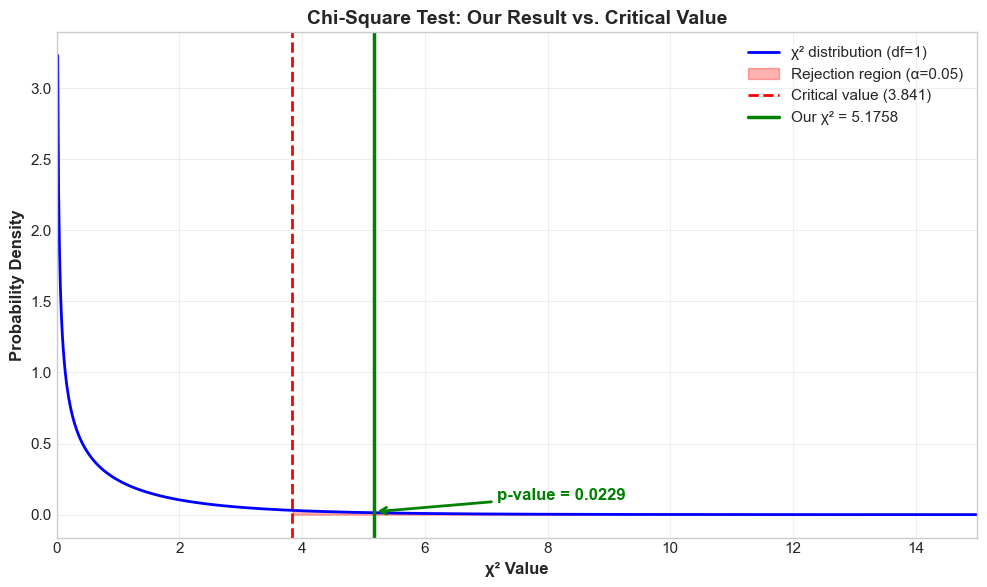

Our χ² = 5.1758 exceeds the critical value of 3.841, so we reject H₀.


In [13]:
# Visualize chi-square test result
fig, ax = plt.subplots(figsize=(10, 6))

# Create chi-square distribution
x = np.linspace(0, 15, 1000)
y = stats.chi2.pdf(x, dof)

# Plot distribution
ax.plot(x, y, 'b-', linewidth=2, label='χ² distribution (df=1)')
ax.fill_between(x[x >= 3.841], 0, stats.chi2.pdf(x[x >= 3.841], dof),
                alpha=0.3, color='red', label='Rejection region (α=0.05)')

# Mark critical value and test statistic
ax.axvline(3.841, color='red', linestyle='--', linewidth=2, label='Critical value (3.841)')
ax.axvline(chi2, color='green', linestyle='-', linewidth=2.5, label=f'Our χ² = {chi2:.4f}')

# Customize
ax.set_xlabel('χ² Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax.set_title('Chi-Square Test: Our Result vs. Critical Value', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 15)

# Add annotation
ax.annotate(f'p-value = {p_value:.4f}',
            xy=(chi2, 0.02), xytext=(chi2 + 2, 0.1),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, fontweight='bold', color='green')

plt.tight_layout()
plt.show()

print(f"Our χ² = {chi2:.4f} exceeds the critical value of 3.841, so we reject H₀.")


## 10. Effect Size Analysis (Cramér's V)

Beyond statistical significance, we need to measure the **strength** of the association.

In [14]:
# Calculate Cramér's V
cramers_v = np.sqrt(chi2 / total_laptops)


print("EFFECT SIZE (CRAMÉR'S V):")


print(f"\nCramér's V = {cramers_v:.4f}")

# Interpret effect size
if cramers_v < 0.1:
    interpretation = "negligible"
elif cramers_v < 0.3:
    interpretation = "small"
elif cramers_v < 0.5:
    interpretation = "medium"
else:
    interpretation = "large"

print(f"\nInterpretation: {interpretation.upper()} effect")

print("\nEffect Size Guidelines (Cohen, 1988):")
print("  • Small:      V ≈ 0.10")
print("  • Medium:     V ≈ 0.30")
print("  • Large:      V ≈ 0.50")

print(f"\nConclusion: The association has a {interpretation} practical effect size.")


EFFECT SIZE (CRAMÉR'S V):

Cramér's V = 0.2439

Interpretation: SMALL effect

Effect Size Guidelines (Cohen, 1988):
  • Small:      V ≈ 0.10
  • Medium:     V ≈ 0.30
  • Large:      V ≈ 0.50

Conclusion: The association has a small practical effect size.


11. Visualization of key results



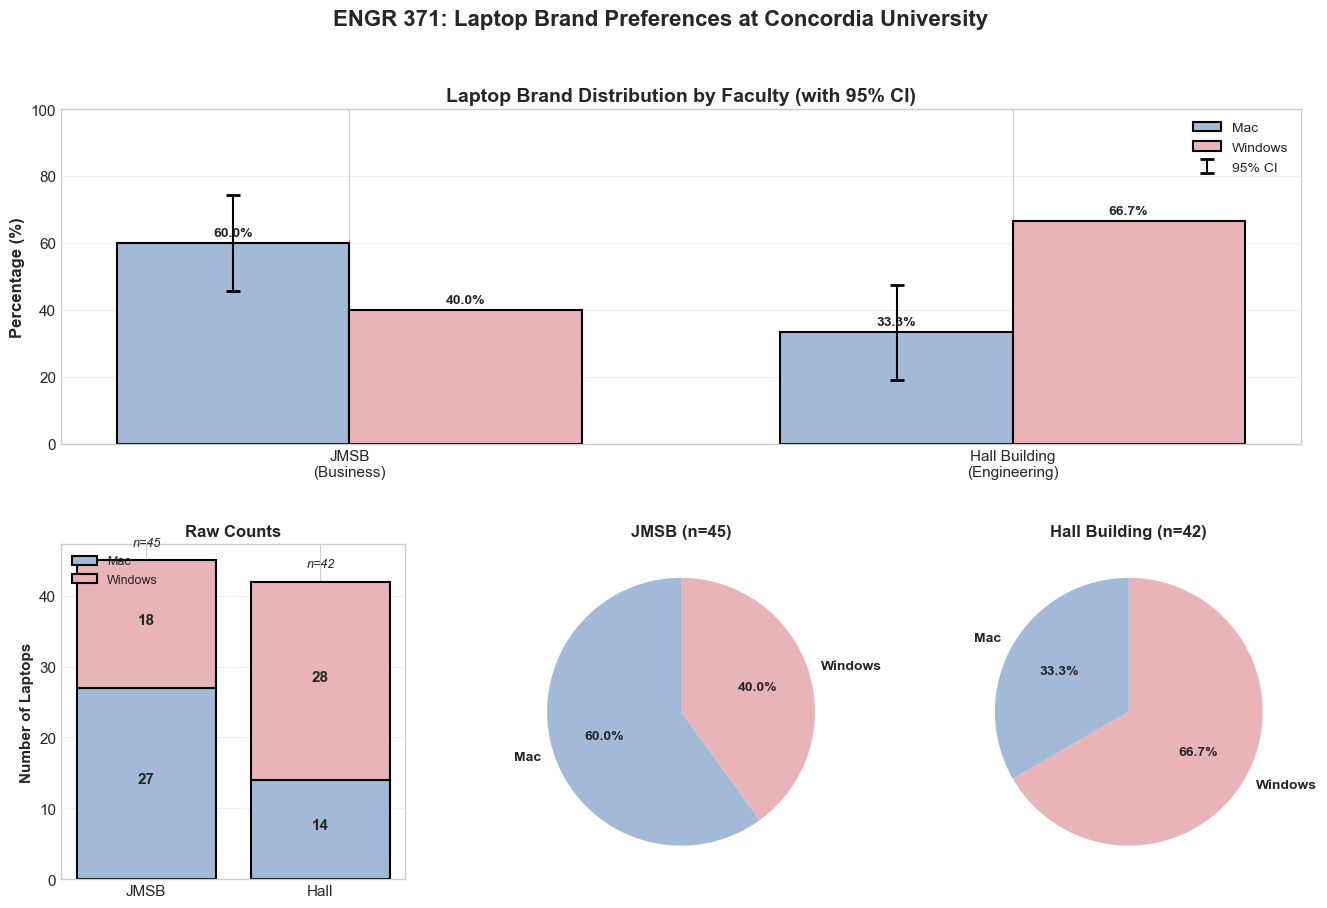

In [15]:
# Create comprehensive figure
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Colors
mac_color = '#A2B9D8'
windows_color = '#E8B4B8'

# 1. Grouped Bar Chart
ax1 = fig.add_subplot(gs[0, :])
x = np.array([0, 1])
width = 0.35

bars1 = ax1.bar(x - width/2, [prop_jmsb_mac*100, prop_hall_mac*100], width,
                label='Mac', color=mac_color, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, [(1-prop_jmsb_mac)*100, (1-prop_hall_mac)*100], width,
                label='Windows', color=windows_color, edgecolor='black', linewidth=1.5)

ax1.errorbar(x - width/2, [prop_jmsb_mac*100, prop_hall_mac*100],
             yerr=[ci_jmsb*100, ci_hall*100], fmt='none', ecolor='black',
             capsize=5, capthick=2, label='95% CI')

ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_title('Laptop Brand Distribution by Faculty (with 95% CI)',
              fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['JMSB\n(Business)', 'Hall Building\n(Engineering)'])
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 100)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 2. Stacked Bar Chart
ax2 = fig.add_subplot(gs[1, 0])
programs = ['JMSB', 'Hall']
mac_counts = [jmsb_macs, hall_macs]
win_counts = [jmsb_windows, hall_windows]

ax2.bar(programs, mac_counts, color=mac_color, edgecolor='black', linewidth=1.5, label='Mac')
ax2.bar(programs, win_counts, bottom=mac_counts, color=windows_color,
        edgecolor='black', linewidth=1.5, label='Windows')

ax2.set_ylabel('Number of Laptops', fontsize=11, fontweight='bold')
ax2.set_title('Raw Counts', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

for i, (m, w) in enumerate(zip(mac_counts, win_counts)):
    ax2.text(i, m/2, str(m), ha='center', fontsize=11, fontweight='bold')
    ax2.text(i, m + w/2, str(w), ha='center', fontsize=11, fontweight='bold')
    ax2.text(i, m + w + 2, f'n={m+w}', ha='center', fontsize=9, style='italic')

# 3. Pie Chart - JMSB
ax3 = fig.add_subplot(gs[1, 1])
ax3.pie([jmsb_macs, jmsb_windows], labels=['Mac', 'Windows'],
        colors=[mac_color, windows_color], autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax3.set_title(f'JMSB (n={jmsb_total})', fontsize=12, fontweight='bold')

# 4. Pie Chart - Hall
ax4 = fig.add_subplot(gs[1, 2])
ax4.pie([hall_macs, hall_windows], labels=['Mac', 'Windows'],
        colors=[mac_color, windows_color], autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax4.set_title(f'Hall Building (n={hall_total})', fontsize=12, fontweight='bold')

plt.suptitle('ENGR 371: Laptop Brand Preferences at Concordia University',
             fontsize=16, fontweight='bold', y=0.98)

plt.show()

## 12. Final Summary Statistics

In [16]:
# Create summary table
summary_stats = {
    'Metric': [
        'Total Observations',
        'JMSB Mac %',
        'Hall Mac %',
        'Difference',
        'Chi-Square (χ²)',
        'P-value',
        "Cramér's V",
        'Effect Size',
        'Statistically Significant'
    ],
    'Value': [
        f'{total_laptops}',
        f'{prop_jmsb_mac*100:.1f}%',
        f'{prop_hall_mac*100:.1f}%',
        f'{diff:.1f} pp',
        f'{chi2:.4f}',
        f'{p_value:.6f}',
        f'{cramers_v:.4f}',
        interpretation.capitalize(),
        'Yes' if p_value < 0.05 else 'No'
    ]
}

summary_df = pd.DataFrame(summary_stats)

print("FINAL SUMMARY STATISTICS")

display(summary_df)

FINAL SUMMARY STATISTICS


,Metric,Value
0,Total Observations,87
1,JMSB Mac %,60.0%
2,Hall Mac %,33.3%
3,Difference,26.7 pp
4,Chi-Square (χ²),5.1758
5,P-value,0.022904
6,Cramér's V,0.2439
7,Effect Size,Small
8,Statistically Significant,Yes


## 13. Key Findings and Conclusions

### Main Results:

1. **Sample:** 87 laptops (45 JMSB, 42 Hall) across 12 observation sessions
2. **JMSB:** 60.0% Mac usage (95% CI: 45.7% - 74.3%)
3. **Hall:** 33.3% Mac usage (95% CI: 19.1% - 47.6%)
4. **Difference:** 26.7 percentage points
5. **Chi-square:** χ² = 5.1758, p = 0.0229
6. **Decision:** **REJECT H₀** - Significant association exists
7. **Effect size:** Cramér's V = 0.2439 (small practical effect)

### Interpretation:

The data support the stereotype of "Business = Mac, Engineering = Windows" with nuance:

- Business students showed higher Mac usage (60.0%)
- Engineering students showed higher Windows usage (66.7%)
- The association was statistically significant (p = 0.0229)
- The effect size was small (V = 0.2439)

**With important nuance:**
- 40.0% of observed JMSB students used Windows laptops
- 33.3% of observed Engineering students used Macs
- The sample contains 87 laptops, below the target of 100
- The pattern is statistically significant but not extreme

**Statistical conclusion:** There is a statistically significant association between academic program and laptop brand preference at Concordia University (χ² = 5.1758, p = 0.0229, V = 0.2439).


In [17]:

print(f"\nKey Finding: JMSB shows {diff:.1f}pp higher Mac usage")
print(f"Statistical Significance: p = {p_value:.4f} < 0.05 ✓")
print(f"Effect Size: Cramér's V = {cramers_v:.4f} ({interpretation})")
print("\nThe stereotype is confirmed with nuance.")



Key Finding: JMSB shows 26.7pp higher Mac usage
Statistical Significance: p = 0.0229 < 0.05 ✓
Effect Size: Cramér's V = 0.2439 (small)

The stereotype is confirmed with nuance.
